# Forward-Axis Detection via Eyes-Nose Differential (ENdif)

Prototype porting the 2D face-detection heuristic of Ramírez, Zanella &
Fuentes (*"Heuristic-based Automatic Face Detection"*) to our 3D head scans.

**The paper's core heuristic (2D grayscale):** in a 9x9 downsample of a face
image, the two eye pixels are *darker* than the nose pixel between them
(eyes are recessed, nose bridge protrudes). They call this quantity the
Eyes-Nose differential (**ENdif**) and maximize it to find a face.

**Our 3D emulation:**
1. Merge Einstar UV-seam duplicates so the geometry is clean.
2. For each candidate camera direction, orthographically rasterize the
   mesh into a *depth image* (closer to camera = brighter). This
   reproduces the paper's "eyes dark, nose bright" contrast directly
   from geometry -- no illumination assumptions, and unaffected by the
   EEG cap (nose still protrudes).
3. Downsample each depth image to 9x9, histogram-equalize, and compute
   ENdif exactly as in the paper.
4. Sweep direction over a Fibonacci sphere and plot ENdif. The argmax
   direction is the forward (anterior) axis; its opposite is the back
   of the head.

Note: world-up is taken as +X (Einstar's rough gravity axis), so the
head renders upright in every view and only the azimuth / elevation
relative to the face matters.

In [24]:
import numpy as np
import trimesh
import matplotlib.pyplot as plt
import scipy.stats
from scipy.ndimage import zoom, gaussian_filter

import cedalion
import cedalion.io
from cedalion.geometry.photogrammetry.anonymization._vertex_utils import (
    deduplicate_vertices,
)

SCANS_FOLDER = '/home/ma7/BA/PG_Subjects'

# Rendering + sweep tunables
IMG_PIXELS   = 80
SMOOTH_SIGMA = 1.2     # Gaussian pre-smooth on depth (pixels)
EYE_OFFSET   = 12      # ENdif horizontal half-spacing (pixels) ~30mm in bin space
MARGIN_FRAC  = 0.2     # skip the outer X% of rows/cols when taking argmax
N_DIRECTIONS = 200
WORLD_UP     = np.array([1.0, 0.0, 0.0])  # +X ~ gravity on Einstar

## 1. Load scan and merge UV-seam duplicates

In [25]:
SUBJECT_NUMBER = 21  # <-- change and rerun from here

path = f'{SCANS_FOLDER}/Subject{SUBJECT_NUMBER}/Subject{SUBJECT_NUMBER}.obj'
surface = cedalion.io.read_einstar_obj(path)
raw_mesh = surface.mesh
print(f'Raw:    {len(raw_mesh.vertices):>7,} vertices, {len(raw_mesh.faces):>7,} faces')

merged_v, old_to_new, _ = deduplicate_vertices(
    np.asarray(raw_mesh.vertices), tol=0.01,
)
merged_faces = old_to_new[np.asarray(raw_mesh.faces)]
# drop degenerate faces (any two corners collapsed to same index)
nondeg = (
    (merged_faces[:, 0] != merged_faces[:, 1]) &
    (merged_faces[:, 1] != merged_faces[:, 2]) &
    (merged_faces[:, 0] != merged_faces[:, 2])
)
merged_faces = merged_faces[nondeg]

mesh = trimesh.Trimesh(vertices=merged_v, faces=merged_faces, process=False)
print(f'Merged: {len(mesh.vertices):>7,} vertices, {len(mesh.faces):>7,} faces')
print(f'        dropped {(~nondeg).sum():,} degenerate faces')

Raw:    494,109 vertices, 866,676 faces
Merged: 433,321 vertices, 866,646 faces
        dropped 30 degenerate faces


## 2. Depth rasterization and ENdif scoring

`depth_image()` orthographically projects the mesh vertices along a camera
direction and bins them into a 2D grid, taking the max depth per cell
(closest vertex to camera wins). This is a render-free, rtree-free
rasterization; at IMG_PIXELS=80 and ~250k head vertices we have >40 verts
per cell so holes are rare.

`endif_score()` reproduces the paper verbatim: downsample to 9x9 with
bilinear interpolation, histogram-equalize, and compute the middle-row
center-minus-flanking-eyes differential.

view = [ 0. -1.  0.]    peak ENdif = +60.6 at (row, col) = (np.int64(49), np.int64(19))


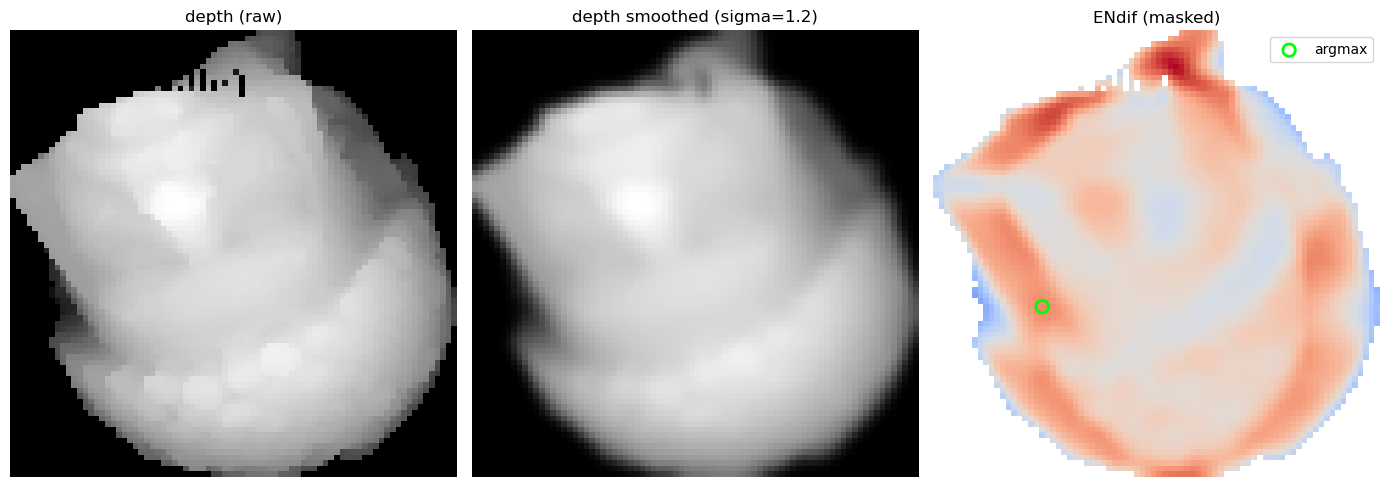

In [26]:
def depth_image(verts, direction, pixels=IMG_PIXELS, world_up=WORLD_UP):
    """Orthographic depth map along `direction`. Brighter = closer to camera.

    Returns (depth, mask) where mask is True inside the head silhouette.
    """
    d = direction / np.linalg.norm(direction)
    u = world_up - (world_up @ d) * d
    if np.linalg.norm(u) < 1e-6:
        u = np.cross(d, np.array([0.0, 1.0, 0.0]))
    u = u / np.linalg.norm(u)
    r = np.cross(u, d)

    x = verts @ r
    y = verts @ u
    depth = verts @ d

    x_e = np.linspace(x.min(), x.max(), pixels + 1)
    y_e = np.linspace(y.min(), y.max(), pixels + 1)
    stat, _, _, _ = scipy.stats.binned_statistic_2d(
        x, y, depth, 'max', [x_e, y_e],
    )
    mask = ~np.isnan(stat)
    stat = np.where(mask, stat, np.nanmin(stat))
    return stat.T, mask.T


def histeq(img, mask=None):
    """Rank-based histogram equalization on the masked region -> [0, 255]."""
    if mask is None:
        mask = np.ones_like(img, dtype=bool)
    out = np.zeros_like(img, dtype=float)
    vals = img[mask].ravel()
    ranks = np.argsort(np.argsort(vals))
    out[mask] = (ranks / max(len(vals) - 1, 1)) * 255.0
    return out


def endif_filter(img_eq, eye_offset=EYE_OFFSET):
    """Local 1D ENdif: center - mean(left_eye, right_eye), peaked horizontally."""
    pad = eye_offset
    padded = np.pad(img_eq, ((0, 0), (pad, pad)), mode='edge')
    left  = padded[:, : -2 * pad]
    right = padded[:, 2 * pad :]
    return img_eq - 0.5 * (left + right)


def score_view(verts_c, direction):
    """Render + smooth + histeq + ENdif + masked argmax for one direction."""
    img, mask = depth_image(verts_c, direction)
    img_s = gaussian_filter(img, SMOOTH_SIGMA)
    img_eq = histeq(img_s, mask)   # kept for visualization only
    en = endif_filter(img_s)       # score on raw mm depth, not equalized ranks

    # Valid region: silhouette interior, away from border, AND upper world half.
    # u ~ +X (gravity), so high row index = upper part of the head -- the nose
    # sits above head center; optodes on the cap are everywhere, so excluding
    # the lower half kills most back-of-head false positives.
    H, W = en.shape
    mr, mc = int(H * MARGIN_FRAC), int(W * MARGIN_FRAC)
    valid = np.zeros_like(mask)
    valid[H // 2 : H - mr, mc : W - mc] = True
    valid &= mask

    en_masked = np.where(valid, en, -np.inf)
    peak = np.unravel_index(en_masked.argmax(), en_masked.shape)
    score = en_masked[peak]
    return score, peak, img, img_s, en, mask


# --- One viewpoint sanity check ---
verts   = np.asarray(mesh.vertices)
verts_c = verts - verts.mean(axis=0)

view = np.array([0.0, -1.0, 0.0])
score, peak, img, img_s, en, mask = score_view(verts_c, view)
print(f'view = {view}    peak ENdif = {score:+.1f} at (row, col) = {peak}')

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(img, cmap='gray', origin='upper')
axes[0].set_title('depth (raw)'); axes[0].axis('off')
axes[1].imshow(img_s, cmap='gray', origin='upper')
axes[1].set_title(f'depth smoothed (sigma={SMOOTH_SIGMA})'); axes[1].axis('off')
m = np.abs(en[mask]).max()
axes[2].imshow(np.where(mask, en, np.nan), cmap='coolwarm',
                origin='upper', vmin=-m, vmax=+m)
axes[2].scatter([peak[1]], [peak[0]], s=80, facecolor='none',
                 edgecolor='lime', lw=2, label='argmax')
axes[2].set_title('ENdif (masked)'); axes[2].axis('off')
axes[2].legend(loc='upper right')
plt.tight_layout()
plt.show()

## 3. Sweep viewpoints on a Fibonacci sphere

For each of `N_DIRECTIONS` uniformly-distributed camera directions on the
sphere we render a depth map, apply the ENdif filter, and record the peak
score. The direction whose peak score is highest is the candidate frontal
direction.

   25/200  current best = +149.7
   50/200  current best = +185.7
   75/200  current best = +203.3
  100/200  current best = +203.3
  125/200  current best = +203.3
  150/200  current best = +203.3
  175/200  current best = +203.3
  200/200  current best = +203.3

best direction : [-0.92141159 -0.05268473  0.385     ]   score = +203.3


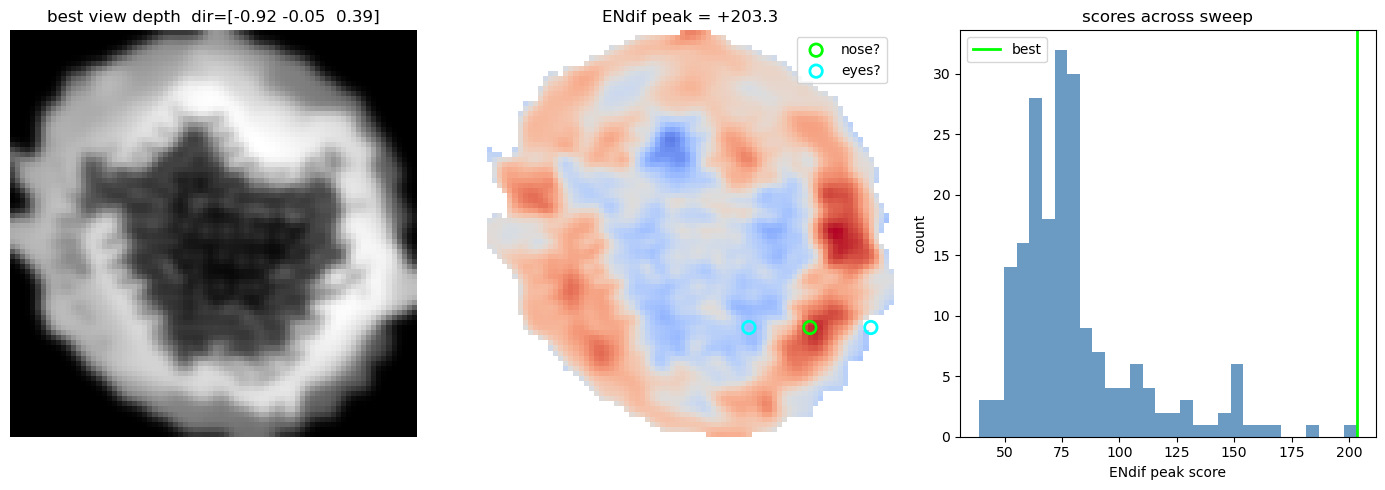

In [27]:
def fibonacci_sphere(n):
    idx = np.arange(n) + 0.5
    phi = np.arccos(1.0 - 2.0 * idx / n)
    theta = np.pi * (1.0 + 5.0 ** 0.5) * idx
    return np.column_stack([
        np.cos(theta) * np.sin(phi),
        np.sin(theta) * np.sin(phi),
        np.cos(phi),
    ])


directions = fibonacci_sphere(N_DIRECTIONS)
scores = np.empty(N_DIRECTIONS)
peaks = [None] * N_DIRECTIONS

for i, d in enumerate(directions):
    s, p, *_ = score_view(verts_c, d)
    scores[i] = s
    peaks[i] = p
    if (i + 1) % 25 == 0:
        print(f'  {i + 1:>3d}/{N_DIRECTIONS}  current best = {scores[:i+1].max():+.1f}')

best_i = int(np.argmax(scores))
best_dir = directions[best_i]
print(f'\nbest direction : {best_dir}   score = {scores[best_i]:+.1f}')

# Visualize the best view
score, peak, img, img_s, en, mask = score_view(verts_c, best_dir)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(img_s, cmap='gray', origin='upper')
axes[0].set_title(f'best view depth  dir={np.round(best_dir, 2)}')
axes[0].axis('off')

m = np.abs(en[mask]).max()
axes[1].imshow(np.where(mask, en, np.nan), cmap='coolwarm',
                origin='upper', vmin=-m, vmax=+m)
axes[1].scatter([peak[1]], [peak[0]], s=80, facecolor='none',
                 edgecolor='lime', lw=2, label='nose?')
# Also mark the candidate eye pixels
axes[1].scatter([peak[1] - EYE_OFFSET, peak[1] + EYE_OFFSET],
                 [peak[0], peak[0]], s=80, facecolor='none',
                 edgecolor='cyan', lw=2, label='eyes?')
axes[1].legend(loc='upper right')
axes[1].set_title(f'ENdif peak = {score:+.1f}'); axes[1].axis('off')

# Score distribution across the sphere for intuition
axes[2].hist(scores, bins=30, color='steelblue', alpha=0.8)
axes[2].axvline(scores[best_i], color='lime', lw=2, label='best')
axes[2].set_xlabel('ENdif peak score'); axes[2].set_ylabel('count')
axes[2].set_title('scores across sweep'); axes[2].legend()
plt.tight_layout()
plt.show()

## 4. Back-project peak pixels onto the 3D mesh

The ENdif peak gives us a (row, col) in the 80x80 depth image of the best
view. To see *where on the scan* those pixels actually are, we find the
mesh vertex that "won" each bin (i.e. the vertex closest to the camera
within that pixel's footprint) and render the mesh with colored spheres
at those 3D positions -- green for the nose candidate, cyan for the two
eye candidates.


In [28]:
import pyvista as pv

def back_project_pixel(verts_c, direction, pixel, pixels=IMG_PIXELS, world_up=WORLD_UP):
    """Return the 3D vertex (in verts_c's frame) that filled `pixel` = (row, col)."""
    d = direction / np.linalg.norm(direction)
    u = world_up - (world_up @ d) * d
    if np.linalg.norm(u) < 1e-6:
        u = np.cross(d, np.array([0.0, 1.0, 0.0]))
    u = u / np.linalg.norm(u)
    r = np.cross(u, d)

    x = verts_c @ r
    y = verts_c @ u
    depth = verts_c @ d

    x_e = np.linspace(x.min(), x.max(), pixels + 1)
    y_e = np.linspace(y.min(), y.max(), pixels + 1)

    row, col = pixel  # row <-> y-bin (u-axis), col <-> x-bin (r-axis)
    in_bin = (
        (x >= x_e[col]) & (x <= x_e[col + 1]) &
        (y >= y_e[row]) & (y <= y_e[row + 1])
    )
    if not in_bin.any():
        return None
    idx_in = np.where(in_bin)[0]
    best = idx_in[np.argmax(depth[in_bin])]
    return best


# Peak is in verts_c frame; re-center output to world frame (verts)
mean = verts.mean(axis=0)

nose_px  = peak
left_px  = (peak[0], peak[1] - EYE_OFFSET)
right_px = (peak[0], peak[1] + EYE_OFFSET)

nose_i  = back_project_pixel(verts_c, best_dir, nose_px)
left_i  = back_project_pixel(verts_c, best_dir, left_px)
right_i = back_project_pixel(verts_c, best_dir, right_px)

nose_xyz  = verts[nose_i]  if nose_i  is not None else None
left_xyz  = verts[left_i]  if left_i  is not None else None
right_xyz = verts[right_i] if right_i is not None else None

print(f'nose vertex  {nose_i}  -> {nose_xyz}')
print(f'left  vertex {left_i}  -> {left_xyz}')
print(f'right vertex {right_i} -> {right_xyz}')

# Radius: ~1% of the mesh diagonal, so spheres are visible but not huge
diag = np.linalg.norm(verts.max(axis=0) - verts.min(axis=0))
rad = diag * 0.01

pl = pv.Plotter(notebook=True)
pv_mesh = pv.PolyData(verts, np.hstack([np.full((len(mesh.faces), 1), 3), mesh.faces]).astype(np.int64))
pl.add_mesh(pv_mesh, color='lightgray', opacity=1.0, show_edges=False)

if nose_xyz is not None:
    pl.add_mesh(pv.Sphere(radius=rad, center=nose_xyz),  color='lime')
if left_xyz is not None:
    pl.add_mesh(pv.Sphere(radius=rad, center=left_xyz),  color='cyan')
if right_xyz is not None:
    pl.add_mesh(pv.Sphere(radius=rad, center=right_xyz), color='cyan')

# Camera: look along -best_dir so the face is toward the viewer
focal = verts.mean(axis=0)
cam_pos = focal + best_dir * diag * 2.0
view_up = WORLD_UP
pl.camera_position = [tuple(cam_pos), tuple(focal), tuple(view_up)]
pl.show()


nose vertex  171341  -> [ 33.034859  36.565964 544.074341]
left  vertex 39998  -> [244.82132   88.176155 463.618439]
right vertex None -> None


Widget(value='<iframe src="http://localhost:41703/index.html?ui=P_0x7fe8fbc99250_4&reconnect=auto" class="pyvi…